In [2]:
import pandas as pd

df_raw = pd.read_excel("Ecosystem-Statistics-UPI-Upi-apps-2025-Jan.xlsx", header=None)
print(df_raw.head(6))

                   0                 1                                2  \
0  UPI Apps (Jan'25)               NaN                              NaN   
1              SrNo.  Application Name  Customer Initiated Transactions   
2                NaN               NaN                      Volume (Mn)   
3                  1        Phone Pe #                          8102.44   
4                  2      Google Pay #                          6183.91   
5                  3           Paytm #                          1152.34   

            3                 4           5                 6           7  \
0         NaN               NaN         NaN               NaN         NaN   
1         NaN  B2C Transactions         NaN  B2B Transactions         NaN   
2  Value (Cr)       Volume (Mn)  Value (Cr)       Volume (Mn)  Value (Cr)   
3  1191303.98                 0           0                 0           0   
4   826845.07                 0           0                 0           0   
5   126313.4

In [4]:
import pandas as pd
import glob
import os
import re
RAW_DIR = "./"
OUT_PATH = "./data.csv"

files = sorted(glob.glob(os.path.join(RAW_DIR, "*.xlsx")))
print(f"Found {len(files)} files")

all_rows = []

for f in files:
    filename = os.path.basename(f)

    match = re.search(r"(\d{4})-([A-Za-z]{3})", filename)
    if not match:
        print(f"WARNING: couldn't parse month from {filename}, skipping")
        continue
    year, month_abbr = match.groups()

    df = pd.read_excel(f, header=[0, 1], skiprows=[0])

    # flatten multi-level columns, dropping "Unnamed" sub-headers
    df.columns = [
        ' '.join([str(c).strip() for c in col if 'Unnamed' not in str(c)]).strip()
        for col in df.columns.values
    ]

    # app name column is just "Application Name" now
    name_col = [c for c in df.columns if c.strip() == 'Application Name'][0]

    # total volume/value columns
    total_vol_col = [c for c in df.columns if 'Total' in c and 'Volume' in c][0]
    total_val_col = [c for c in df.columns if 'Total' in c and 'Value' in c][0]

    df_clean = df[[name_col, total_vol_col, total_val_col]].copy()
    df_clean.columns = ["app_name", "volume_mn", "value_cr"]

    # clean app name
    df_clean["app_name"] = (
        df_clean["app_name"].astype(str).str.replace("#", "", regex=False).str.strip()
    )

    # drop junk rows (blank/NaN app names)
    df_clean = df_clean.dropna(subset=["app_name"])
    df_clean = df_clean[df_clean["app_name"].str.lower() != "nan"]

    df_clean["month"] = f"{year}-{month_abbr}"
    all_rows.append(df_clean)

combined = pd.concat(all_rows, ignore_index=True)
combined.to_csv(OUT_PATH, index=False)
print(f"Saved {len(combined)} rows to {OUT_PATH}")
print(f"Months processed: {sorted(combined['month'].unique())}")
print(f"Unique app names ({combined['app_name'].nunique()}):")
print(sorted(combined["app_name"].unique()))

Found 7 files
Saved 581 rows to ./data.csv
Months processed: ['2025-Apr', '2025-Feb', '2025-Jan', '2025-Jul', '2025-Jun', '2025-Mar', '2025-May']
Unique app names (91):
['AU Small Finance Bank Apps', 'Aditya Birla Capital Digital', 'Airtel Payments Bank Apps', 'Amazon Pay', 'Axis Bank Apps', 'BHIM', 'Bajaj Finserv', 'Bank of Baroda Apps', 'Bank of India Apps', 'Bank of Maharashtra Apps', 'Bharat Pe', 'Canara Bank Apps', 'Central Bank of India Apps', 'Cheq', 'City Union Bank Apps', 'Cred', 'DBS Digibank Apps', 'Deutsche Bank Apps', 'Dhani', 'Digikhata', 'ESAF Small Finance Bank Apps', 'Equitas Small Finance Bank Apps', 'FamApp by Trio', 'Federal Bank Apps', 'Fi Money', 'Fino Payments Bank Apps', 'Flipkart UPI', 'Freo', 'Genwise', 'Google Pay', 'Groww', 'HDFC Bank Apps', 'HSBC Bank Apps', 'ICICI Bank Apps', 'IDBI Bank Apps', 'IDFC Bank Apps', 'Ind Money', 'India Post Payments Bank Apps', 'Indian Bank Apps', 'Indian Overseas Bank Apps', 'IndusInd Bank Apps', 'Jammu and Kashmir Bank Apps',

In [5]:
df = pd.read_excel("Ecosystem-Statistics-UPI-Upi-apps-2025-Jan.xlsx", header=[0, 1], skiprows=[0])
print(df.columns.tolist())

[('SrNo.', 'Unnamed: 0_level_1'), ('Application Name', 'Unnamed: 1_level_1'), ('Customer Initiated Transactions', 'Volume (Mn)'), ('Customer Initiated Transactions', 'Value (Cr)'), ('B2C Transactions', 'Volume (Mn)'), ('B2C Transactions', 'Value (Cr)'), ('B2B Transactions', 'Volume (Mn)'), ('B2B Transactions', 'Value (Cr)'), ('Total', 'Volume (Mn)'), ('Total', 'Value (Cr)')]


In [6]:
print(len(files))
for f in files:
    if not re.search(r"(\d{4})-([A-Za-z]{3})", os.path.basename(f)):
        print("BAD FILENAME:", f)

7


In [7]:
name_map = {
    # PhonePe
    'Phone Pe': 'PhonePe',
    # Paytm
    'Paytm (OCL )': 'Paytm',
    'Paytm (OCL)': 'Paytm',
    # WhatsApp
    'Whatsapp': 'WhatsApp',

    # Obopay
    'OBOPAY': 'Obopay',
    # OmniCard
    'Omni Card': 'OmniCard',
    'Omnicard': 'OmniCard',

    # Aditya Birla
    'Aditya Birla Capital Digital Limited': 'Aditya Birla Capital Digital',
    # Freo
    'Freo Money': 'Freo',
    # Kredit Pe
    'Kredit.Pe': 'Kredit Pe',
    # Rapipay
    'Rapi Pay': 'Rapipay',
    # Fampay / FamApp cluster - these look like the same evolving brand
    'Fam App by Trio': 'FamApp by Trio',
    'Fam Pay by Trio': 'FamApp by Trio',
    'Fampay by Trio': 'FamApp by Trio',
    'Fampay': 'FamApp by Trio',
    'FAM': 'FamApp by Trio',
    # Go Kiwi / Kiwi (rebrand)
    'Go Kiwi': 'Kiwi',
    'Gokiwi': 'Kiwi',
    # Pop Club
    'POPClub': 'Pop Club',

}

combined['app_name'] = combined['app_name'].replace(name_map)

print(f"Unique app names after cleaning: {combined['app_name'].nunique()}")
print(sorted(combined['app_name'].unique()))

Unique app names after cleaning: 90
['AU Small Finance Bank Apps', 'Aditya Birla Capital Digital', 'Airtel Payments Bank Apps', 'Amazon Pay', 'Axis Bank Apps', 'BHIM', 'Bajaj Finserv', 'Bank of Baroda Apps', 'Bank of India Apps', 'Bank of Maharashtra Apps', 'Bharat Pe', 'Canara Bank Apps', 'Central Bank of India Apps', 'Cheq', 'City Union Bank Apps', 'Cred', 'DBS Digibank Apps', 'Deutsche Bank Apps', 'Dhani', 'Digikhata', 'ESAF Small Finance Bank Apps', 'Equitas Small Finance Bank Apps', 'FamApp by Trio', 'Federal Bank Apps', 'Fi Money', 'Fino Payments Bank Apps', 'Flipkart UPI', 'Freo', 'Genwise', 'Google Pay', 'Groww', 'HDFC Bank Apps', 'HSBC Bank Apps', 'ICICI Bank Apps', 'IDBI Bank Apps', 'IDFC Bank Apps', 'Ind Money', 'India Post Payments Bank Apps', 'Indian Bank Apps', 'Indian Overseas Bank Apps', 'IndusInd Bank Apps', 'Jammu and Kashmir Bank Apps', 'Jar', 'Jio Payments Bank Apps', 'Jupiter Money', 'Karnataka Bank Apps', 'Karur Vysya Bank Apps', 'Kiwi', 'Kotak Mahindra Bank Apps'

In [8]:
combined.to_csv(OUT_PATH, index=False)

In [9]:
print(combined['volume_mn'].dtype)
print(combined[combined['volume_mn'].apply(lambda x: not str(x).replace('.', '', 1).replace('-', '', 1).isdigit())]['volume_mn'].unique())

float64
[]


In [10]:
# convert to numeric, coercing anything unparseable to NaN
combined['volume_mn'] = (
    combined['volume_mn']
    .astype(str)
    .str.replace(',', '', regex=False)   # remove thousand-separator commas
    .str.strip()
)
combined['volume_mn'] = pd.to_numeric(combined['volume_mn'], errors='coerce')

combined['value_cr'] = (
    combined['value_cr']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)
combined['value_cr'] = pd.to_numeric(combined['value_cr'], errors='coerce')

# check how many rows became NaN (couldn't be converted)
print("Rows with NaN volume after conversion:", combined['volume_mn'].isna().sum())
print("Rows with NaN value after conversion:", combined['value_cr'].isna().sum())

Rows with NaN volume after conversion: 0
Rows with NaN value after conversion: 0


In [11]:
top_apps = combined.groupby('app_name')['volume_mn'].sum().sort_values(ascending=False)
print(top_apps.head(15))

app_name
PhonePe                     58929.29
Google Pay                  45310.28
Paytm                        8576.11
Navi                         2408.49
super.money                  1286.15
Cred                          968.06
Axis Bank Apps                879.89
Amazon Pay                    695.04
FamApp by Trio                694.07
WhatsApp                      465.75
ICICI Bank Apps               430.70
HDFC Bank Apps                411.60
Kotak Mahindra Bank Apps      405.75
BHIM                          395.26
Yes Bank Apps                 333.35
Name: volume_mn, dtype: float64


In [12]:
combined.to_csv(OUT_PATH, index=False)
print("Saved cleaned data to", OUT_PATH)

Saved cleaned data to ./data.csv


In [13]:
import collections

lower_groups = collections.defaultdict(set)
for name in combined['app_name'].unique():
    lower_groups[name.lower()].add(name)

case_dupes = {k: v for k, v in lower_groups.items() if len(v) > 1}
print("Case-only duplicates found:")
for k, v in case_dupes.items():
    print(v)

Case-only duplicates found:


In [14]:
canonical = (
    combined.groupby(combined['app_name'].str.lower())['app_name']
    .agg(lambda x: x.value_counts().idxmax())
)
combined['app_name'] = combined['app_name'].str.lower().map(canonical)

print(f"Unique app names after case-normalization: {combined['app_name'].nunique()}")

Unique app names after case-normalization: 90


In [15]:
combined['app_name'] = combined['app_name'].replace(name_map)

top_apps = combined.groupby('app_name')['volume_mn'].sum().sort_values(ascending=False)
print(top_apps.head(15))

app_name
PhonePe                     58929.29
Google Pay                  45310.28
Paytm                        8576.11
Navi                         2408.49
super.money                  1286.15
Cred                          968.06
Axis Bank Apps                879.89
Amazon Pay                    695.04
FamApp by Trio                694.07
WhatsApp                      465.75
ICICI Bank Apps               430.70
HDFC Bank Apps                411.60
Kotak Mahindra Bank Apps      405.75
BHIM                          395.26
Yes Bank Apps                 333.35
Name: volume_mn, dtype: float64


In [16]:
combined.to_csv(OUT_PATH, index=False)
print("Saved cleaned data to", OUT_PATH)

Saved cleaned data to ./data.csv


In [17]:
print(f"Total unique apps: {combined['app_name'].nunique()}")
print(f"Total months: {combined['month'].nunique()}")
print(f"Total rows: {len(combined)}")

Total unique apps: 90
Total months: 7
Total rows: 581


In [19]:
import glob
files = sorted(glob.glob("../data/raw/monthly/*.xlsx"))
print(f"Files in folder: {len(files)}")
for f in files:
    print(f)

Files in folder: 0


In [ ]:
import sys
!"{sys.executable}" -m pip install matplotlib seaborn

In [ ]:
conn = sqlite3.connect("../data/processed/cred_upi.db")

query = """
SELECT month, app_name, volume_mn,
       volume_mn * 1.0 / SUM(volume_mn) OVER (PARTITION BY month) AS market_share
FROM app_monthly
WHERE app_name IN ('PhonePe', 'Google Pay', 'Paytm', 'CRED', 'Navi', 'super.money')
ORDER BY app_name, month;
"""

top_apps_trend = pd.read_sql(query, conn)
conn.close()

# fix month sorting same way as before
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
top_apps_trend[['year', 'mon']] = top_apps_trend['month'].str.split('-', expand=True)
top_apps_trend['mon_num'] = top_apps_trend['mon'].apply(lambda x: month_order.index(x) + 1)
top_apps_trend['month_sorted'] = pd.to_datetime(
    top_apps_trend['year'] + '-' + top_apps_trend['mon_num'].astype(str), format='%Y-%m'
)
top_apps_trend = top_apps_trend.sort_values(['app_name', 'month_sorted']).reset_index(drop=True)

print(top_apps_trend.head(10))

      month app_name  volume_mn  market_share  year  mon  mon_num month_sorted
0  2024-Jan     CRED     108.86      0.010582  2024  Jan        1   2024-01-01
1  2024-Feb     CRED     111.53      0.009515  2024  Feb        2   2024-02-01
2  2024-Mar     CRED     132.31      0.010234  2024  Mar        3   2024-03-01
3  2024-Apr     CRED     138.46      0.010819  2024  Apr        4   2024-04-01
4  2024-May     CRED     140.08      0.010484  2024  May        5   2024-05-01
5  2024-Jun     CRED     138.42      0.010567  2024  Jun        6   2024-06-01
6  2024-Jul     CRED     142.56      0.010430  2024  Jul        7   2024-07-01
7  2024-Aug     CRED     147.48      0.010418  2024  Aug        8   2024-08-01
8  2024-Sep     CRED     140.00      0.009861  2024  Sep        9   2024-09-01
9  2024-Oct     CRED     152.28      0.009742  2024  Oct       10   2024-10-01


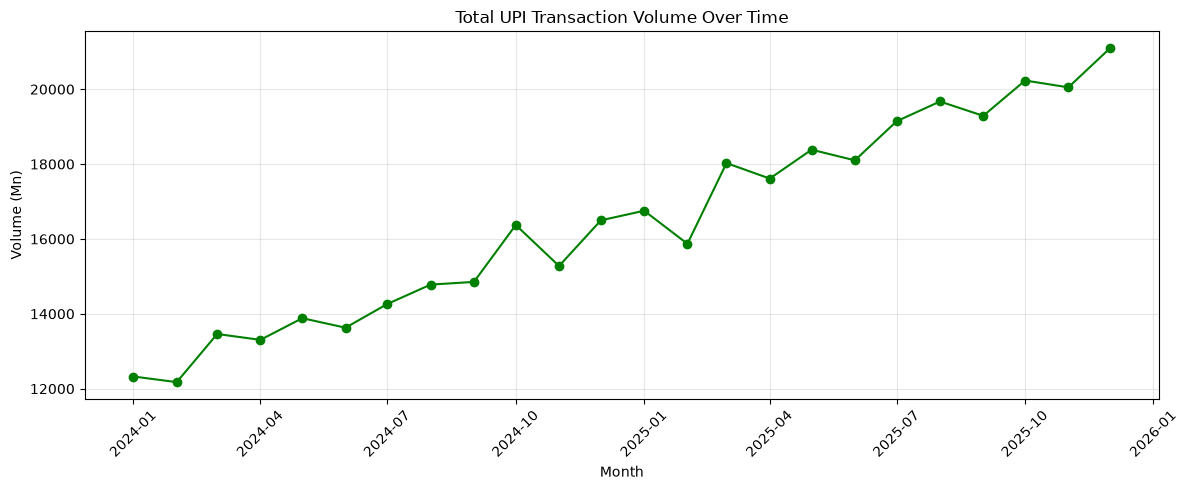

In [ ]:
conn = sqlite3.connect("../data/processed/cred_upi.db")

query2 = """
SELECT month, SUM(volume_mn) as total_volume, SUM(value_cr) as total_value
FROM app_monthly
GROUP BY month;
"""

totals = pd.read_sql(query2, conn)
conn.close()

totals[['year', 'mon']] = totals['month'].str.split('-', expand=True)
totals['mon_num'] = totals['mon'].apply(lambda x: month_order.index(x) + 1)
totals['month_sorted'] = pd.to_datetime(totals['year'] + '-' + totals['mon_num'].astype(str), format='%Y-%m')
totals = totals.sort_values('month_sorted').reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(totals['month_sorted'], totals['total_volume'], marker='o', color='green')
plt.title('Total UPI Transaction Volume Over Time')
plt.ylabel('Volume (Mn)')
plt.xlabel('Month')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../dashboard/total_volume_trend.png', dpi=150)
plt.show()

In [ ]:
totals = totals.sort_values('month_sorted').reset_index(drop=True)
totals['time_index'] = range(len(totals))  # 0, 1, 2, ... one per monthZ

print(totals[['month_sorted', 'total_volume', 'time_index']])

   month_sorted  total_volume  time_index
0    2024-01-01      12325.59           0
1    2024-02-01      12175.04           1
2    2024-03-01      13460.81           2
3    2024-04-01      13304.51           3
4    2024-05-01      13883.44           4
5    2024-06-01      13629.10           5
6    2024-07-01      14263.87           6
7    2024-08-01      14780.89           7
8    2024-09-01      14852.68           8
9    2024-10-01      16373.53           9
10   2024-11-01      15277.59          10
11   2024-12-01      16497.60          11
12   2025-01-01      16753.55          12
13   2025-02-01      15871.03          13
14   2025-03-01      18026.60          14
15   2025-04-01      17613.14          15
16   2025-05-01      18384.44          16
17   2025-06-01      18100.00          17
18   2025-07-01      19145.28          18
19   2025-08-01      19672.25          19
20   2025-09-01      19289.15          20
21   2025-10-01      20232.81          21
22   2025-11-01      20049.89     

In [ ]:
split_point = int(len(totals) * 0.70)

train = totals.iloc[:split_point]
test = totals.iloc[split_point:]

print(f"Train: {len(train)} months, Test: {len(test)} months")
print(f"Train range: {train['month_sorted'].min()} to {train['month_sorted'].max()}")
print(f"Test range: {test['month_sorted'].min()} to {test['month_sorted'].max()}")

Train: 19 months, Test: 5 months
Train range: 2024-01-01 00:00:00 to 2025-07-01 00:00:00
Test range: 2025-08-01 00:00:00 to 2025-12-01 00:00:00


In [ ]:
import sys
!"{sys.executable}" -m pip install scikit-learn


In [ ]:
split_point = int(len(totals) * 0.8)
train = totals.iloc[:split_point]
test = totals.iloc[split_point:]
print(f"Train: {len(train)} months, Test: {len(test)} months")

Train: 19 months, Test: 5 months


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

X_train = train[['time_index']]
y_train = train['total_volume']
X_test = test[['time_index']]
y_test = test['total_volume']

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Monthly growth: {model.coef_[0]:.2f} million transactions/month")
print(f"Test MAE: {mae:.2f} million transactions")
print(f"Test R²: {r2:.4f}")

Monthly growth: 368.61 million transactions/month
Test MAE: 346.26 million transactions
Test R²: 0.6560


In [ ]:
totals = totals.sort_values('month_sorted').reset_index(drop=True)
totals['time_index'] = range(len(totals))
print(totals[['month_sorted', 'total_volume', 'time_index']])

   month_sorted  total_volume  time_index
0    2024-01-01      12325.59           0
1    2024-02-01      12175.04           1
2    2024-03-01      13460.81           2
3    2024-04-01      13304.51           3
4    2024-05-01      13883.44           4
5    2024-06-01      13629.10           5
6    2024-07-01      14263.87           6
7    2024-08-01      14780.89           7
8    2024-09-01      14852.68           8
9    2024-10-01      16373.53           9
10   2024-11-01      15277.59          10
11   2024-12-01      16497.60          11
12   2025-01-01      16753.55          12
13   2025-02-01      15871.03          13
14   2025-03-01      18026.60          14
15   2025-04-01      17613.14          15
16   2025-05-01      18384.44          16
17   2025-06-01      18100.00          17
18   2025-07-01      19145.28          18
19   2025-08-01      19672.25          19
20   2025-09-01      19289.15          20
21   2025-10-01      20232.81          21
22   2025-11-01      20049.89     